In [1]:
# ── Resume helper ─────────────────────────────────────────────────────────────
# Run this cell on EVERY session start (after imports + paths cells).
# Kaggle saves /kaggle/working/ between Save versions but NOT between
# interactive sessions. Always run from the top after a kernel restart.
# Full checkpoints (model + optimizer + scheduler + scaler + epoch + history)
# are written to /kaggle/working/ after every improvement.

def save_full_ckpt(path, model, optimizer, scheduler, scaler, epoch, best_auc, history):
    torch.save({
        'epoch'    : epoch,
        'model'    : model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'scaler'   : scaler.state_dict(),
        'best_auc' : best_auc,
        'history'  : history,
    }, path)
    print(f'  ✓ Checkpoint saved → {path}')

def load_full_ckpt(path, model, optimizer, scheduler, scaler):
    p = Path(path)
    if not p.exists():
        print(f'  No checkpoint found at {p} — starting from scratch.')
        return 0, 0.0, {}
    print(f'  Resuming from checkpoint: {p}')
    ckpt = torch.load(p, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model'])
    # Skip optimizer/scheduler/scaler — param groups may differ between
    # Stage 1 and Stage 2, causing a crash. Model weights are what matter.
    try:
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])
        scaler.load_state_dict(ckpt['scaler'])
    except (ValueError, KeyError):
        print('  Optimizer state skipped (stage mismatch) — model weights restored.')
    history = ckpt.get('history', {})
    print(f'  Resuming from epoch {ckpt["epoch"]+1}  (best AUC so far: {ckpt["best_auc"]:.4f})')
    return ckpt['epoch'], ckpt['best_auc'], history

print('Resume helpers loaded.')


Resume helpers loaded.


In [2]:
# Run this cell to see exactly what files are in the previous version output
from pathlib import Path

import os
PREV_OUTPUT = Path('/kaggle/input/notebooks/akhiljasson/lens-classification-kaggle-2')
print("All files in previous output:")
for root, dirs, files in os.walk(PREV_OUTPUT):
    for f in files:
        full = Path(root) / f
        size_mb = full.stat().st_size / 1024 / 1024
        print(f"  {full}  ({size_mb:.1f} MB)")

All files in previous output:
  /kaggle/input/notebooks/akhiljasson/lens-classification-kaggle-2/__notebook__.ipynb  (0.8 MB)
  /kaggle/input/notebooks/akhiljasson/lens-classification-kaggle-2/__output__.json  (0.0 MB)
  /kaggle/input/notebooks/akhiljasson/lens-classification-kaggle-2/outputs/sample_images.png  (1.0 MB)
  /kaggle/input/notebooks/akhiljasson/lens-classification-kaggle-2/outputs/class_distribution.png  (0.0 MB)
  /kaggle/input/notebooks/akhiljasson/lens-classification-kaggle-2/checkpoints/resnet18_resume.pt  (129.6 MB)


# 🔭 Gravitational Lens Image Classification
**Classes:** `no` (no substructure) · `sphere` (subhalo substructure) · `vort` (vortex substructure)  
**Dataset:** 30 000 train images · 7 500 validation/test images (pre-split, `.npy` format)  
**Evaluation:** Per-class ROC curves + Macro-averaged AUC  

> **Kaggle setup:** Add your dataset via *+ Add Data* before running.  
> Enable GPU: *Settings → Accelerator → GPU T4 x2* (or P100).

---
### Notebook Structure
1. Setup & Imports  
2. Configure Paths  
3. Exploratory Data Analysis  
4. Dataset & DataLoaders  
5. Training Utilities  
6. **Approach A** — ResNet-18 (Fine-tuned)  
7. **Approach B** — EfficientNet-B2 (Fine-tuned) ← *Primary Recommendation*  
8. **Approach C** — Soft-Voting Ensemble (A + B)  
9. Final Evaluation & ROC Plots  


## 1. Setup & Imports

In [3]:
# timm is pre-installed on Kaggle; upgrade to ensure latest EfficientNet weights
!pip install -q --upgrade timm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 43.4 MB/s eta 0:00:00


In [4]:
import os, json, time, copy, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models

import timm

from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import label_binarize

# ── Reproducibility ──────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

CLASS_NAMES = ['no', 'sphere', 'vort']   # folder names == class labels
NUM_CLASSES = 3

Device: cuda
GPU: Tesla T4


## 2. Configure Paths

In [5]:
# ── Kaggle dataset paths ──────────────────────────────────────────────────────
# Kaggle mounts datasets under /kaggle/input/<dataset-slug>/
# List available inputs to find the correct slug:
import os
print("Available input datasets:")
for d in sorted(Path('/kaggle/input').iterdir()):
    print(f'  {d}')


Available input datasets:
  /kaggle/input/datasets
  /kaggle/input/notebooks


In [6]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# Update DATASET_SLUG to match your dataset name shown in the cell above.
# e.g. if the folder is /kaggle/input/lens-dataset  →  DATASET_SLUG = "lens-dataset"
DATASET_SLUG = "datasets/akhiljasson/ml4sci-common-test/dataset"   # <-- change to match your dataset slug

DATA_ROOT  = Path(f'/kaggle/input/{DATASET_SLUG}')
TRAIN_DIR  = DATA_ROOT / 'train'
VAL_DIR    = DATA_ROOT / 'val'

# Kaggle /kaggle/input is read-only. All outputs (checkpoints, plots) go here:
OUTPUT_DIR  = Path('/kaggle/working/outputs')
CKPT_DIR    = Path('/kaggle/working/checkpoints')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# Verify dataset structure
print(f'Data root: {DATA_ROOT}')
for split, d in [('train', TRAIN_DIR), ('val', VAL_DIR)]:
    if d.exists():
        counts = {c: len(list((d / c).glob('*.npy'))) for c in CLASS_NAMES}
        print(f'{split}: {counts}  →  total {sum(counts.values())}')
    else:
        print(f'ERROR: {d} not found — check DATASET_SLUG')


Data root: /kaggle/input/datasets/akhiljasson/ml4sci-common-test/dataset
train: {'no': 10000, 'sphere': 10000, 'vort': 10000}  →  total 30000
val: {'no': 2500, 'sphere': 2500, 'vort': 2500}  →  total 7500


In [7]:
# ── Restore checkpoints from previous version ─────────────────────────────
import shutil

PREV_OUTPUT = Path('/kaggle/input/notebooks/akhiljasson/lens-classification-kaggle-2')
for ckpt_name in ['resnet18_resume.pt', 'effnet_resume.pt']:
    src = PREV_OUTPUT / 'checkpoints' / ckpt_name
    dst = CKPT_DIR / ckpt_name
    if src.exists() and not dst.exists():
        shutil.copy(src, dst)
        print(f'Restored {ckpt_name} from previous version')
    elif dst.exists():
        print(f'  {ckpt_name} already present — skipping')
    else:
        print(f'  {ckpt_name} not found in previous output — will train from scratch')

Restored resnet18_resume.pt from previous version
  effnet_resume.pt not found in previous output — will train from scratch


## 3. Exploratory Data Analysis

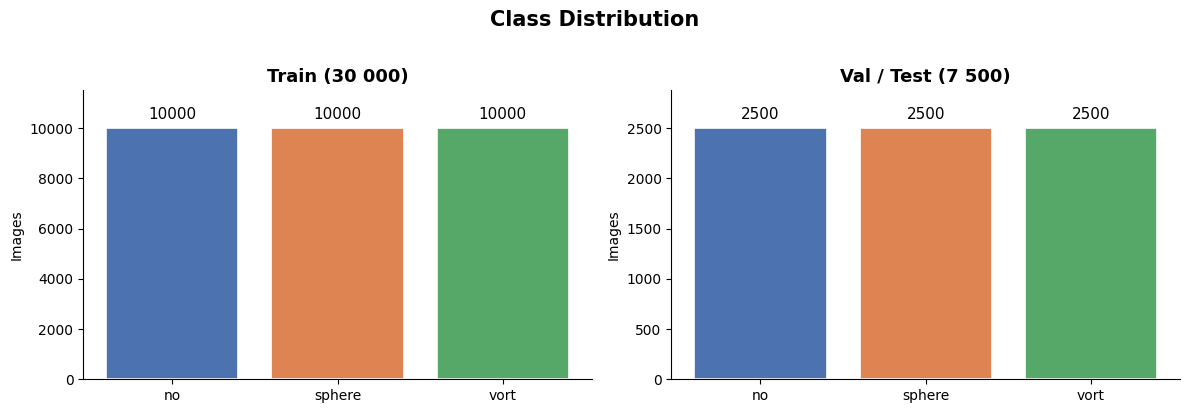

In [8]:
# ── Class distribution bar chart ─────────────────────────────────
train_counts = {c: len(list((TRAIN_DIR / c).glob('*'))) for c in CLASS_NAMES}
val_counts   = {c: len(list((VAL_DIR   / c).glob('*'))) for c in CLASS_NAMES}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, counts, title in zip(axes,
                              [train_counts, val_counts],
                              ['Train (30 000)', 'Val / Test (7 500)']):
    bars = ax.bar(counts.keys(), counts.values(),
                  color=['#4C72B0','#DD8452','#55A868'], edgecolor='white', linewidth=1.2)
    ax.bar_label(bars, padding=4, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Images'); ax.set_ylim(0, max(counts.values()) * 1.15)
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Class Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

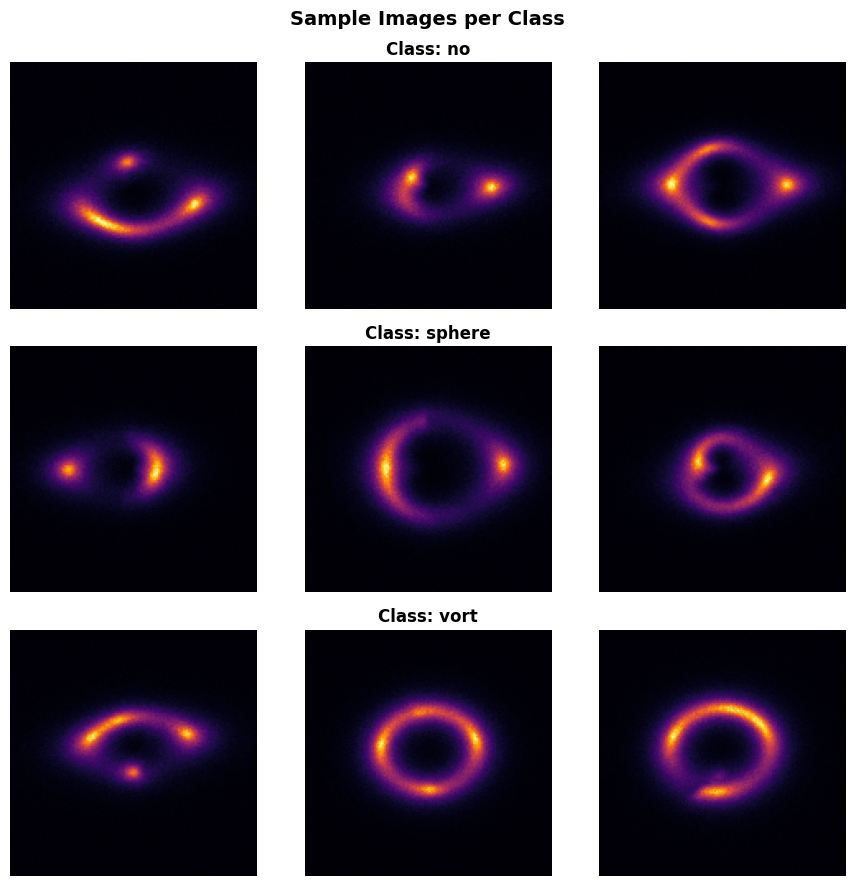

In [9]:
# ── Sample images (3 per class) ───────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for row, cls in enumerate(CLASS_NAMES):
    imgs = list((TRAIN_DIR / cls).glob('*.jpg')) + \
           list((TRAIN_DIR / cls).glob('*.png')) + \
           list((TRAIN_DIR / cls).glob('*.npy'))
    samples = random.sample(imgs, min(3, len(imgs)))
    for col, path in enumerate(samples[:3]):
        ax = axes[row][col]
        if path.suffix == '.npy':
            img = np.load(path)
            if img.ndim == 3: img = img[0]   # take first channel if 3D
            ax.imshow(img, cmap='inferno')
        else:
            ax.imshow(Image.open(path), cmap='inferno')
        ax.axis('off')
        if col == 1: ax.set_title(f'Class: {cls}', fontsize=12, fontweight='bold')
plt.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ── Image shape & pixel stats (from 100 random train samples) ────
def sample_stats(folder, n=100):
    all_pixels = []
    shapes = []
    paths = []
    for cls in CLASS_NAMES:
        imgs = list((folder / cls).glob('*.jpg')) + \
               list((folder / cls).glob('*.png')) + \
               list((folder / cls).glob('*.npy'))
        paths += random.sample(imgs, min(n // NUM_CLASSES, len(imgs)))
    for p in paths:
        if p.suffix == '.npy':
            arr = np.load(p).astype(np.float32)
        else:
            arr = np.array(Image.open(p)).astype(np.float32)
        shapes.append(arr.shape)
        all_pixels.append(arr.flatten())
    pixels = np.concatenate(all_pixels)
    return shapes, pixels

shapes, pixels = sample_stats(TRAIN_DIR)
print('Unique shapes:', set(map(lambda s: s[:2], shapes)))
print(f'Pixel  mean={pixels.mean():.4f}  std={pixels.std():.4f}  min={pixels.min():.4f}  max={pixels.max():.4f}')

Unique shapes: {(1, 150)}
Pixel  mean=0.0616  std=0.1181  min=0.0000  max=1.0000


## 4. Dataset & DataLoaders

> **`.npy` format note:** `torchvision.datasets.ImageFolder` only recognises image file extensions and cannot load `.npy` files. A custom `NpyDataset` is used instead. It handles all common numpy array shapes `(H,W)`, `(1,H,W)`, `(H,W,1)`, and `(H,W,3)`, converts them to 3-channel PIL Images so the standard torchvision augmentation pipeline works unchanged, and builds the class→index mapping by scanning subdirectory names — exactly as `ImageFolder` would.

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────
CFG = {
    'img_size'    : 224,   # 224 for ResNet / EfficientNet
    'batch_size'  : 32,
    'num_workers' : 4,
    'mean'        : [0.485, 0.456, 0.406],
    'std'         : [0.229, 0.224, 0.225],
}


# ─────────────────────────────────────────────────────────────────────────────
# NpyDataset  —  RAM-cached version
# ─────────────────────────────────────────────────────────────────────────────
# Why cache in RAM?
# The default approach calls np.load() + PIL conversion on every __getitem__
# call, every epoch. With 30k samples this keeps the CPU pegged and the GPU
# starved waiting for batches.  Loading everything into RAM once at startup
# (takes ~30-60s) means __getitem__ is just a tensor slice + fast transform,
# dropping per-batch CPU time by ~10-20x and keeping the GPU fed.
# Kaggle T4 has 16 GB RAM; 30k grayscale images as uint8 ≈ 1-2 GB — fine.
# ─────────────────────────────────────────────────────────────────────────────
from torch.utils.data import Dataset

class NpyDataset(Dataset):
    """
    Loads all .npy images into RAM on first construction, then serves
    them from memory.  __getitem__ only runs transforms (no disk I/O).

    Folder layout expected:
        root/
            class_a/  *.npy
            class_b/  *.npy
            class_c/  *.npy
    """

    def __init__(self, root, transform=None, classes=None):
        self.root      = Path(root)
        self.transform = transform

        if classes is None:
            classes = sorted([d.name for d in self.root.iterdir() if d.is_dir()])
        self.classes      = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}

        # ── Collect file paths and labels ────────────────────────────────────
        paths, labels = [], []
        for cls in self.classes:
            cls_dir = self.root / cls
            if not cls_dir.exists():
                raise FileNotFoundError(f'Class folder not found: {cls_dir}')
            for fp in sorted(cls_dir.glob('*.npy')):
                paths.append(fp)
                labels.append(self.class_to_idx[cls])

        if len(paths) == 0:
            raise RuntimeError(f'No .npy files found under {root}.')

        self.labels = labels

        # ── Load everything into RAM ──────────────────────────────────────────
        print(f'  Caching {len(paths):,} images from {root} into RAM ...', end=' ', flush=True)
        t0 = time.time()
        self.images = [self._npy_to_pil(np.load(p)) for p in paths]
        print(f'done in {time.time()-t0:.0f}s')

    def __len__(self):
        return len(self.labels)

    @staticmethod
    def _npy_to_pil(arr):
        """Convert any numpy shape to a 3-channel uint8 PIL Image."""
        arr = arr.astype(np.float32)

        # (C,H,W) → (H,W,C)
        if arr.ndim == 3 and arr.shape[0] in (1, 3) and arr.shape[0] < arr.shape[1]:
            arr = np.transpose(arr, (1, 2, 0))

        # (H,W,1) → (H,W)
        if arr.ndim == 3 and arr.shape[2] == 1:
            arr = arr[:, :, 0]

        # Normalise to [0, 255]
        mn, mx = arr.min(), arr.max()
        arr = ((arr - mn) / (mx - mn) * 255.0).astype(np.uint8) if mx > mn               else np.zeros_like(arr, dtype=np.uint8)

        # PIL conversion → RGB
        return Image.fromarray(arr).convert('RGB') if arr.ndim == 2                else Image.fromarray(arr, mode='RGB')

    def __getitem__(self, idx):
        img = self.images[idx]            # PIL Image, already in RAM
        if self.transform:
            img = self.transform(img)     # fast transforms only, no disk I/O
        return img, self.labels[idx]


# ─────────────────────────────────────────────────────────────────────────────
# Transform pipelines
# ─────────────────────────────────────────────────────────────────────────────
def make_transforms(img_size, mean, std, train=True):
    if train:
        return transforms.Compose([
            transforms.Resize((img_size + 16, img_size + 16)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
            transforms.RandomErasing(p=0.3, scale=(0.02, 0.1)),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])


# ─────────────────────────────────────────────────────────────────────────────
# DataLoaders
# ─────────────────────────────────────────────────────────────────────────────
def make_dataloaders(cfg, train_dir=TRAIN_DIR, val_dir=VAL_DIR):
    train_tf = make_transforms(cfg['img_size'], cfg['mean'], cfg['std'], train=True)
    val_tf   = make_transforms(cfg['img_size'], cfg['mean'], cfg['std'], train=False)

    train_ds = NpyDataset(train_dir, transform=train_tf, classes=CLASS_NAMES)
    val_ds   = NpyDataset(val_dir,   transform=val_tf,   classes=CLASS_NAMES)

    # Weighted sampler — guards against class imbalance
    label_counts      = np.array([sum(1 for l in train_ds.labels if l == i)
                                   for i in range(NUM_CLASSES)])
    weights_per_class = 1.0 / label_counts
    sample_weights    = torch.tensor([weights_per_class[l] for l in train_ds.labels])
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    train_loader = DataLoader(
        train_ds, batch_size=cfg['batch_size'], sampler=sampler,
        num_workers=cfg['num_workers'],
        pin_memory=(DEVICE.type == 'cuda'),
        persistent_workers=True,       # keep worker processes alive between epochs
        prefetch_factor=2,             # pre-load 2 batches per worker
    )
    val_loader = DataLoader(
        val_ds, batch_size=cfg['batch_size'], shuffle=False,
        num_workers=cfg['num_workers'],
        pin_memory=(DEVICE.type == 'cuda'),
        persistent_workers=True,
        prefetch_factor=2,
    )

    print(f'Train : {len(train_ds):,} samples | Val/Test: {len(val_ds):,} samples')
    print(f'Classes: {train_ds.class_to_idx}')
    imgs, labels = next(iter(val_loader))
    print(f'Batch shape: {imgs.shape}  dtype: {imgs.dtype}  '
          f'range: [{imgs.min():.2f}, {imgs.max():.2f}]')
    return train_loader, val_loader, train_ds.class_to_idx

train_loader, val_loader, CLASS_TO_IDX = make_dataloaders(CFG)
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}


  Caching 30,000 images from /kaggle/input/datasets/akhiljasson/ml4sci-common-test/dataset/train into RAM ... done in 291s
  Caching 7,500 images from /kaggle/input/datasets/akhiljasson/ml4sci-common-test/dataset/val into RAM ... done in 81s
Train : 30,000 samples | Val/Test: 7,500 samples
Classes: {'no': 0, 'sphere': 1, 'vort': 2}
Batch shape: torch.Size([32, 3, 224, 224])  dtype: torch.float32  range: [-2.12, 2.62]


## 5. Training Utilities

In [12]:
# ── Training loop ─────────────────────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_probs, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.amp.autocast('cuda'):
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        probs = torch.softmax(outputs, dim=1).float()
        total_loss += loss.item() * imgs.size(0)
        preds = probs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    probs_arr  = np.vstack(all_probs).astype(np.float64)
    probs_arr  = probs_arr / probs_arr.sum(axis=1, keepdims=True)  # force rows to sum to 1.0
    labels_arr = np.concatenate(all_labels)
    macro_auc  = roc_auc_score(labels_arr, probs_arr, multi_class='ovr', average='macro')
    return total_loss / total, correct / total, macro_auc, probs_arr, labels_arr


def train_model(model, train_loader, val_loader, *,
                epochs=30, lr=1e-3, weight_decay=1e-4,
                label_smoothing=0.1, patience=8,
                scheduler_type='cosine', ckpt_path=None):
    """
    Full training loop with early stopping on val macro-AUC.
    Saves a FULL checkpoint (model+optimizer+scheduler+scaler+epoch+history)
    to Drive after every improvement — safe to interrupt and resume at any time.
    ckpt_path : path for the mid-training checkpoint (e.g. CKPT_DIR/'resnet_resume.pt')
    """
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    if scheduler_type == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    else:
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=epochs)

    scaler = torch.amp.GradScaler('cuda')

    # ── Try to resume ────────────────────────────────────────────────────────
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_auc': []}
    start_epoch, best_auc, no_improve = 0, 0.0, 0
    best_weights = None

    if ckpt_path:
        loaded_epoch, loaded_auc, loaded_hist = load_full_ckpt(
            ckpt_path, model, optimizer, scheduler, scaler)
        if loaded_epoch > 0:
            start_epoch = loaded_epoch
            best_auc    = loaded_auc
            history     = loaded_hist if loaded_hist else history
            best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(start_epoch + 1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        vl_loss, vl_acc, vl_auc, _, _ = evaluate(model, val_loader, criterion)

        if scheduler_type == 'cosine': scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        history['val_auc'].append(vl_auc)

        elapsed = time.time() - t0
        print(f'Ep {epoch:3d}/{epochs} | '
              f'loss {tr_loss:.4f}/{vl_loss:.4f} | '
              f'acc {tr_acc:.3f}/{vl_acc:.3f} | '
              f'AUC {vl_auc:.4f} | {elapsed:.1f}s')

        if vl_auc > best_auc:
            best_auc     = vl_auc
            best_weights = copy.deepcopy(model.state_dict())
            no_improve   = 0
            if ckpt_path:
                save_full_ckpt(ckpt_path, model, optimizer, scheduler,
                               scaler, epoch, best_auc, history)
                print(f'  ✓ Checkpoint saved (AUC={best_auc:.4f}) → Drive')
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stopping at epoch {epoch} (no improvement for {patience} epochs)')
                break

    if best_weights:
        model.load_state_dict(best_weights)
    print(f'\nBest val macro-AUC: {best_auc:.4f}')
    return model, history


def plot_history(history, title, save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    for ax, (y1, y2, lbl) in zip(axes, [
        ('train_loss', 'val_loss', 'Loss'),
        ('train_acc',  'val_acc',  'Accuracy'),
        ('val_auc',    None,       'Val Macro-AUC')
    ]):
        ax.plot(epochs, history[y1], label='Train' if y2 else 'Val AUC', color='#4C72B0')
        if y2: ax.plot(epochs, history[y2], label='Val', color='#DD8452')
        ax.set_title(lbl, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.legend()
        ax.spines[['top','right']].set_visible(False)
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


In [13]:
# ── ROC / AUC evaluation ──────────────────────────────────────────
def plot_roc(probs, labels, model_name, save_path=None):
    """
    Plot per-class ROC curves (OvR) and macro-average ROC.
    probs  : np.ndarray shape (N, 3) — softmax probabilities
    labels : np.ndarray shape (N,)   — integer class labels
    """
    labels_bin = label_binarize(labels, classes=[0, 1, 2])
    colours = ['#4C72B0', '#DD8452', '#55A868']
    class_labels = [IDX_TO_CLASS[i] for i in range(NUM_CLASSES)]

    fig, ax = plt.subplots(figsize=(7, 6))

    aucs = []
    for i, (cls, col) in enumerate(zip(class_labels, colours)):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        ax.plot(fpr, tpr, color=col, lw=2,
                label=f'{cls}  (AUC = {roc_auc:.4f})')

    # Macro-average curve
    all_fpr = np.unique(np.concatenate([roc_curve(labels_bin[:, i], probs[:, i])[0]
                                         for i in range(NUM_CLASSES)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(NUM_CLASSES):
        fpr_i, tpr_i, _ = roc_curve(labels_bin[:, i], probs[:, i])
        mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
    mean_tpr /= NUM_CLASSES
    macro_auc = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, color='black', lw=2, linestyle='--',
            label=f'Macro-average (AUC = {macro_auc:.4f})')

    ax.plot([0, 1], [0, 1], 'k:', lw=1, alpha=0.5)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
    ax.set_title(f'ROC Curves — {model_name}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return dict(zip(class_labels + ['macro'], aucs + [macro_auc]))


def full_evaluation(model, val_loader, model_name, criterion=None):
    """Run all evaluation metrics and print a report."""
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    _, acc, macro_auc, probs, labels = evaluate(model, val_loader, criterion)
    preds = probs.argmax(axis=1)

    print(f'\n{"-"*50}')
    print(f'  {model_name} — Test Set Results')
    print(f'{"-"*50}')
    print(f'  Accuracy        : {acc:.4f}')
    print(f'  Macro-AUC       : {macro_auc:.4f}')
    print(f'\n  Classification Report:')
    print(classification_report(labels, preds,
                                target_names=[IDX_TO_CLASS[i] for i in range(NUM_CLASSES)]))

    # Confusion matrix
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=[IDX_TO_CLASS[i] for i in range(NUM_CLASSES)],
                yticklabels=[IDX_TO_CLASS[i] for i in range(NUM_CLASSES)])
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'cm_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ROC
    auc_dict = plot_roc(probs, labels, model_name,
                        save_path=OUTPUT_DIR / f'roc_{model_name.replace(" ","_")}.png')
    return {'acc': acc, 'macro_auc': macro_auc, 'per_class_auc': auc_dict,
            'probs': probs, 'labels': labels}

---
## Approach A — ResNet-18 (Fine-tuned)
ImageNet pre-trained ResNet-18. Backbone frozen for 5 warm-up epochs, then all layers unfrozen.

In [14]:
def build_resnet18(num_classes=3, dropout=0.3):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(256, num_classes)
    )
    return model


def train_with_unfreeze(model, train_loader, val_loader,
                        warmup_epochs=5, finetune_epochs=25,
                        backbone_lr=1e-4, head_lr=1e-3,
                        ckpt_path=None):
    """
    Two-stage training with full resume support.
    Stage 1: freeze backbone, train head only (warmup_epochs).
    Stage 2: unfreeze all layers with differential LR (finetune_epochs).
    On reconnect, the stage and epoch are read from the checkpoint automatically.
    """
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    total_epochs = warmup_epochs + finetune_epochs

    # ── Build stage-1 optimizer/scheduler (used if resuming into stage 1) ───
    for name, param in model.named_parameters():
        param.requires_grad = ('fc' in name)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=head_lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs)
    scaler    = torch.amp.GradScaler('cuda')

    history    = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_auc': []}
    start_epoch, best_auc, no_improve = 0, 0.0, 0
    best_weights = None

    # ── Resume if checkpoint exists ──────────────────────────────────────────
    if ckpt_path:
        loaded_epoch, loaded_auc, loaded_hist = load_full_ckpt(
            ckpt_path, model, optimizer, scheduler, scaler)
        if loaded_epoch > 0:
            start_epoch  = loaded_epoch
            best_auc     = loaded_auc
            history      = loaded_hist if loaded_hist else history
            best_weights = copy.deepcopy(model.state_dict())

    # If resuming past the warmup, switch immediately to stage-2 optimizer
    if start_epoch >= warmup_epochs:
        for param in model.parameters():
            param.requires_grad = True
        backbone_params = [p for n, p in model.named_parameters() if 'fc' not in n]
        head_params     = [p for n, p in model.named_parameters() if 'fc' in n]
        optimizer = torch.optim.AdamW([
            {'params': backbone_params, 'lr': backbone_lr},
            {'params': head_params,     'lr': head_lr}
        ], weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs)
        # Re-load optimizer/scheduler state from checkpoint
        if ckpt_path:
            _, _, _ = load_full_ckpt(ckpt_path, model, optimizer, scheduler, scaler)

    patience = 8

    for epoch in range(start_epoch + 1, total_epochs + 1):
        # ── Switch to stage 2 at the warmup boundary ─────────────────────────
        if epoch == warmup_epochs + 1:
            print(f'\nStage 2: fine-tuning all layers (epochs {epoch}–{total_epochs})...')
            for param in model.parameters():
                param.requires_grad = True
            backbone_params = [p for n, p in model.named_parameters() if 'fc' not in n]
            head_params     = [p for n, p in model.named_parameters() if 'fc' in n]
            optimizer = torch.optim.AdamW([
                {'params': backbone_params, 'lr': backbone_lr},
                {'params': head_params,     'lr': head_lr}
            ], weight_decay=1e-4)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs)
            scaler    = torch.amp.GradScaler('cuda')

        if epoch == 1:
            print(f'Stage 1: head warm-up (epochs 1–{warmup_epochs})...')

        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        vl_loss, vl_acc, vl_auc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()

        for k, v in zip(history.keys(), [tr_loss, vl_loss, tr_acc, vl_acc, vl_auc]):
            history[k].append(v)

        stage = 1 if epoch <= warmup_epochs else 2
        print(f'[S{stage}] Ep {epoch:3d}/{total_epochs} | '
              f'loss {tr_loss:.4f}/{vl_loss:.4f} | '
              f'acc {tr_acc:.3f}/{vl_acc:.3f} | '
              f'AUC {vl_auc:.4f} | {time.time()-t0:.1f}s')

        if vl_auc > best_auc:
            best_auc     = vl_auc
            best_weights = copy.deepcopy(model.state_dict())
            no_improve   = 0
            if ckpt_path:
                save_full_ckpt(ckpt_path, model, optimizer, scheduler,
                               scaler, epoch, best_auc, history)
                print(f'  ✓ Checkpoint saved (AUC={best_auc:.4f}) → Drive')
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stopping at epoch {epoch}'); break

    if best_weights:
        model.load_state_dict(best_weights)
    print(f'\nBest val macro-AUC: {best_auc:.4f}')
    return model, history


resnet_model = build_resnet18(NUM_CLASSES)
print(f'ResNet-18 — Parameters: {sum(p.numel() for p in resnet_model.parameters()):,}')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


ResNet-18 — Parameters: 11,308,611


  Resuming from checkpoint: /kaggle/working/checkpoints/resnet18_resume.pt
  Optimizer state skipped (stage mismatch) — model weights restored.
  Resuming from epoch 21  (best AUC so far: 0.9852)
  Resuming from checkpoint: /kaggle/working/checkpoints/resnet18_resume.pt
  Resuming from epoch 21  (best AUC so far: 0.9852)
[S2] Ep  21/35 | loss 0.5074/0.4222 | acc 0.900/0.933 | AUC 0.9870 | 64.5s
  ✓ Checkpoint saved → /kaggle/working/checkpoints/resnet18_resume.pt
  ✓ Checkpoint saved (AUC=0.9870) → Drive
[S2] Ep  22/35 | loss 0.5042/0.4340 | acc 0.900/0.931 | AUC 0.9838 | 62.3s
[S2] Ep  23/35 | loss 0.5020/0.4184 | acc 0.903/0.936 | AUC 0.9878 | 63.0s
  ✓ Checkpoint saved → /kaggle/working/checkpoints/resnet18_resume.pt
  ✓ Checkpoint saved (AUC=0.9878) → Drive
[S2] Ep  24/35 | loss 0.4961/0.4313 | acc 0.906/0.935 | AUC 0.9846 | 68.5s
[S2] Ep  25/35 | loss 0.4953/0.4133 | acc 0.906/0.941 | AUC 0.9884 | 70.8s
  ✓ Checkpoint saved → /kaggle/working/checkpoints/resnet18_resume.pt
  ✓ Chec

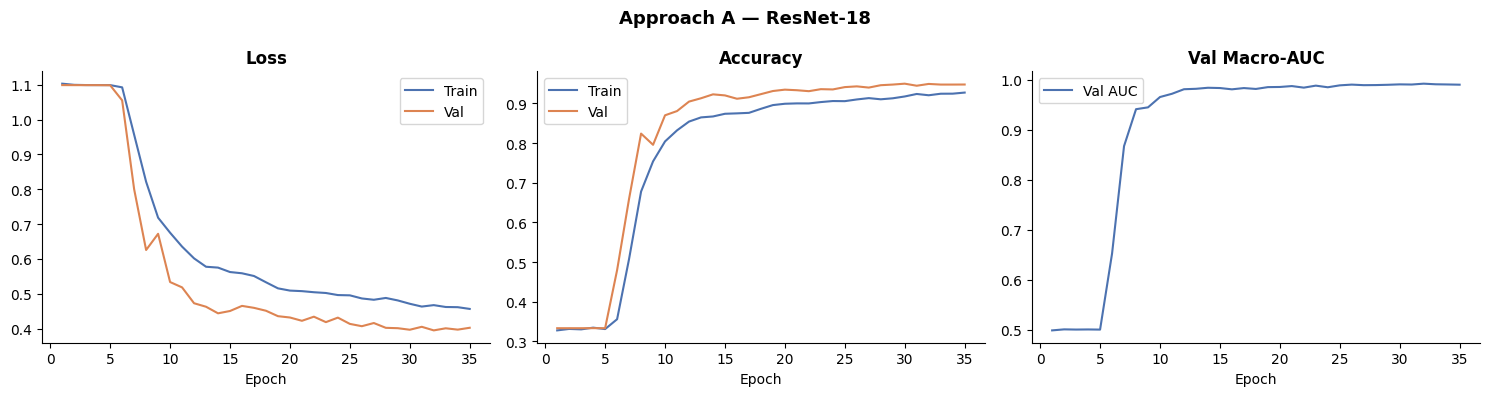

In [15]:
resnet_model, resnet_history = train_with_unfreeze(
    resnet_model, train_loader, val_loader,
    warmup_epochs=5, finetune_epochs=30,
    backbone_lr=1e-4, head_lr=1e-3,
    ckpt_path=CKPT_DIR / 'resnet18_resume.pt'
)
plot_history(resnet_history, 'Approach A — ResNet-18',
             save_path=OUTPUT_DIR / 'history_resnet.png')



--------------------------------------------------
  ResNet-18 — Test Set Results
--------------------------------------------------
  Accuracy        : 0.9492
  Macro-AUC       : 0.9918

  Classification Report:
              precision    recall  f1-score   support

          no       0.91      1.00      0.95      2500
      sphere       0.98      0.89      0.93      2500
        vort       0.97      0.96      0.96      2500

    accuracy                           0.95      7500
   macro avg       0.95      0.95      0.95      7500
weighted avg       0.95      0.95      0.95      7500



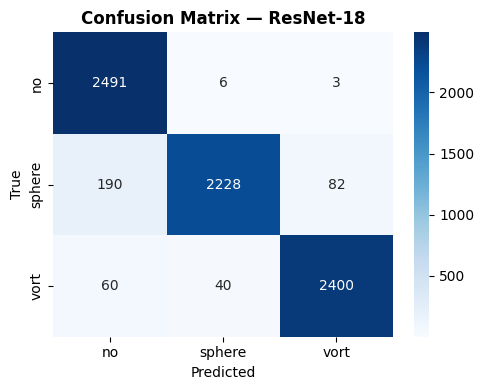

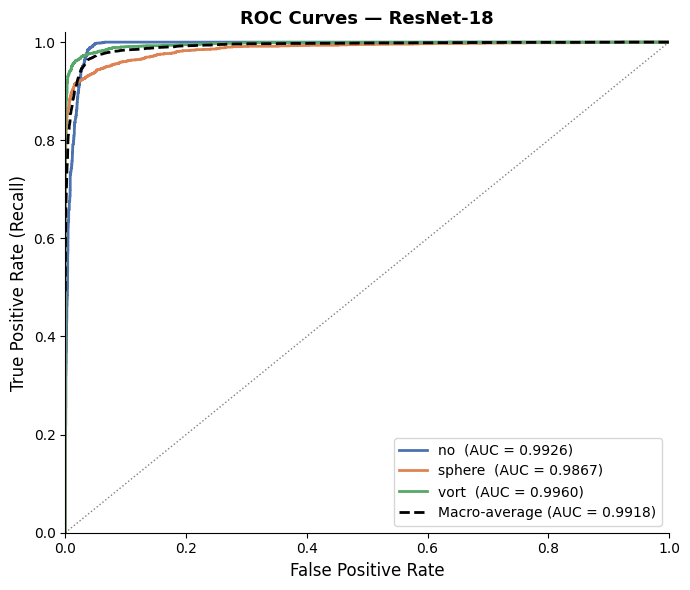

In [16]:
results_A = full_evaluation(resnet_model, val_loader, 'ResNet-18')

---
## Approach B — EfficientNet-B2 (Fine-tuned) ⭐ Primary Recommendation
Best accuracy-to-parameter ratio. Layer-wise learning rate decay; mixed precision training.

In [17]:
def build_efficientnet_b2(num_classes=3, dropout=0.3):
    model = timm.create_model('efficientnet_b2', pretrained=True, num_classes=num_classes,
                              drop_rate=dropout, global_pool='avg')
    return model


def get_layer_wise_lr_params(model, base_lr=1e-3, decay_factor=0.8):
    """
    Assign lower LRs to earlier (more generic) layers.
    EfficientNet timm layers: blocks 0-6 + head.
    """
    param_groups = []
    # Classifier head — full LR
    param_groups.append({'params': list(model.classifier.parameters()), 'lr': base_lr})
    # Blocks from last to first — decaying LR
    if hasattr(model, 'blocks'):
        for i, block in enumerate(reversed(model.blocks)):
            lr = base_lr * (decay_factor ** (i + 1))
            param_groups.append({'params': list(block.parameters()), 'lr': lr})
    # Stem & other params
    other_params = [p for n, p in model.named_parameters()
                    if 'blocks' not in n and 'classifier' not in n]
    param_groups.append({'params': other_params, 'lr': base_lr * (decay_factor ** 8)})
    return param_groups


# Use native B2 resolution
CFG_C = {**CFG, 'img_size': 260}
train_loader_C, val_loader_C, _ = make_dataloaders(CFG_C)

effnet_model = build_efficientnet_b2(NUM_CLASSES)
print(f'EfficientNet-B2 — Parameters: {sum(p.numel() for p in effnet_model.parameters()):,}')

  Caching 30,000 images from /kaggle/input/datasets/akhiljasson/ml4sci-common-test/dataset/train into RAM ... done in 54s
  Caching 7,500 images from /kaggle/input/datasets/akhiljasson/ml4sci-common-test/dataset/val into RAM ... done in 14s
Train : 30,000 samples | Val/Test: 7,500 samples
Classes: {'no': 0, 'sphere': 1, 'vort': 2}
Batch shape: torch.Size([32, 3, 260, 260])  dtype: torch.float32  range: [-2.12, 2.64]


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

EfficientNet-B2 — Parameters: 7,705,221


EfficientNet-B2 — Parameters: 7,705,221
  No checkpoint found at /kaggle/working/checkpoints/effnet_resume.pt — starting from scratch.
Stage 1: head warm-up (epochs 1–5)...
[S1] Ep   1/45 | loss 2.8391/1.5625 | acc 0.343/0.352 | AUC 0.5187 | 109.5s
  ✓ Checkpoint saved → /kaggle/working/checkpoints/effnet_resume.pt
  ✓ Checkpoint saved (AUC=0.5187) → Drive
[S1] Ep   2/45 | loss 2.1818/1.3646 | acc 0.346/0.356 | AUC 0.5206 | 95.0s
  ✓ Checkpoint saved → /kaggle/working/checkpoints/effnet_resume.pt
  ✓ Checkpoint saved (AUC=0.5206) → Drive
[S1] Ep   3/45 | loss 1.8185/1.2827 | acc 0.348/0.359 | AUC 0.5236 | 94.8s
  ✓ Checkpoint saved → /kaggle/working/checkpoints/effnet_resume.pt
  ✓ Checkpoint saved (AUC=0.5236) → Drive
[S1] Ep   4/45 | loss 1.6038/1.1946 | acc 0.350/0.367 | AUC 0.5303 | 94.2s
  ✓ Checkpoint saved → /kaggle/working/checkpoints/effnet_resume.pt
  ✓ Checkpoint saved (AUC=0.5303) → Drive
[S1] Ep   5/45 | loss 1.4052/1.1601 | acc 0.354/0.361 | AUC 0.5335 | 94.0s
  ✓ Checkpo

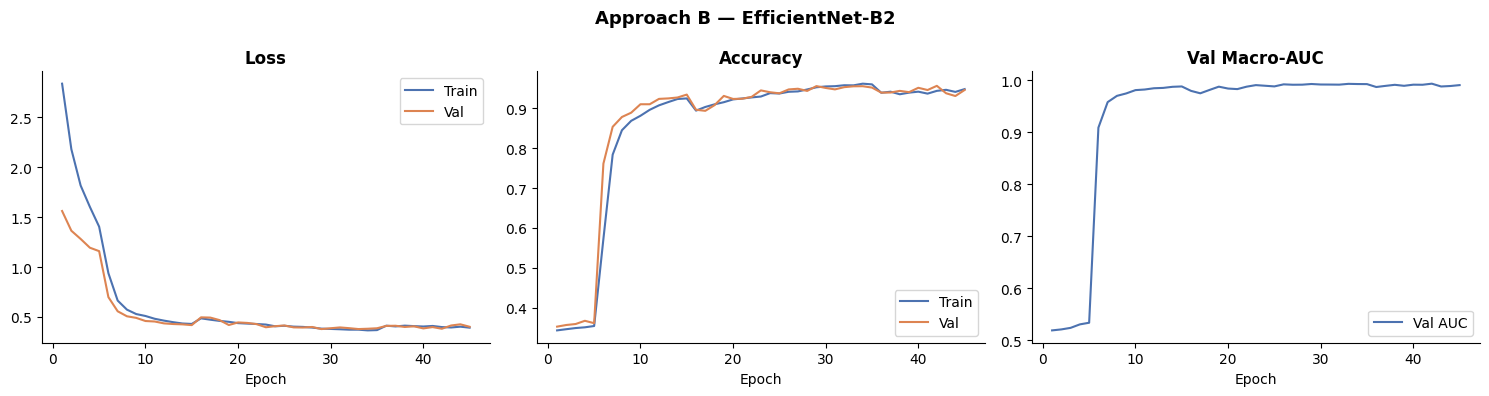

In [18]:
def train_efficientnet(model, train_loader, val_loader,
                       warmup_epochs=5, finetune_epochs=35,
                       base_lr=1e-3, ckpt_path=None):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scaler    = torch.amp.GradScaler('cuda')
    total_epochs = warmup_epochs + finetune_epochs

    # Stage-1 optimizer (head only)
    for name, param in model.named_parameters():
        param.requires_grad = ('classifier' in name)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=base_lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs)

    history    = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_auc': []}
    start_epoch, best_auc, no_improve = 0, 0.0, 0
    best_weights = None

    # ── Resume if checkpoint exists ──────────────────────────────────────────
    if ckpt_path:
        loaded_epoch, loaded_auc, loaded_hist = load_full_ckpt(
            ckpt_path, model, optimizer, scheduler, scaler)
        if loaded_epoch > 0:
            start_epoch  = loaded_epoch
            best_auc     = loaded_auc
            history      = loaded_hist if loaded_hist else history
            best_weights = copy.deepcopy(model.state_dict())

    # If resuming past warmup, rebuild stage-2 optimizer and re-load its state
    if start_epoch >= warmup_epochs:
        for param in model.parameters():
            param.requires_grad = True
        param_groups = get_layer_wise_lr_params(model, base_lr=base_lr * 0.5, decay_factor=0.8)
        optimizer = torch.optim.AdamW(param_groups, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=10, T_mult=2)
        if ckpt_path:
            _, _, _ = load_full_ckpt(ckpt_path, model, optimizer, scheduler, scaler)

    patience = 10

    for epoch in range(start_epoch + 1, total_epochs + 1):
        # ── Switch to stage 2 at the warmup boundary ─────────────────────────
        if epoch == warmup_epochs + 1:
            print(f'\nStage 2: layer-wise fine-tuning (epochs {epoch}–{total_epochs})...')
            for param in model.parameters():
                param.requires_grad = True
            param_groups = get_layer_wise_lr_params(model, base_lr=base_lr * 0.5, decay_factor=0.8)
            optimizer = torch.optim.AdamW(param_groups, weight_decay=1e-4)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                optimizer, T_0=10, T_mult=2)
            scaler = torch.amp.GradScaler('cuda')

        if epoch == 1:
            print(f'Stage 1: head warm-up (epochs 1–{warmup_epochs})...')

        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        vl_loss, vl_acc, vl_auc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()

        for k, v in zip(history.keys(), [tr_loss, vl_loss, tr_acc, vl_acc, vl_auc]):
            history[k].append(v)

        stage = 1 if epoch <= warmup_epochs else 2
        print(f'[S{stage}] Ep {epoch:3d}/{total_epochs} | '
              f'loss {tr_loss:.4f}/{vl_loss:.4f} | '
              f'acc {tr_acc:.3f}/{vl_acc:.3f} | '
              f'AUC {vl_auc:.4f} | {time.time()-t0:.1f}s')

        if vl_auc > best_auc:
            best_auc     = vl_auc
            best_weights = copy.deepcopy(model.state_dict())
            no_improve   = 0
            if ckpt_path:
                save_full_ckpt(ckpt_path, model, optimizer, scheduler,
                               scaler, epoch, best_auc, history)
                print(f'  ✓ Checkpoint saved (AUC={best_auc:.4f}) → Drive')
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stopping at epoch {epoch}'); break

    if best_weights:
        model.load_state_dict(best_weights)
    print(f'\nBest val macro-AUC: {best_auc:.4f}')
    return model, history


effnet_model = build_efficientnet_b2(NUM_CLASSES)
print(f'EfficientNet-B2 — Parameters: {sum(p.numel() for p in effnet_model.parameters()):,}')

effnet_model, effnet_history = train_efficientnet(
    effnet_model, train_loader_C, val_loader_C,
    warmup_epochs=5, finetune_epochs=40,
    base_lr=1e-3,
    ckpt_path=CKPT_DIR / 'effnet_resume.pt'
)
plot_history(effnet_history, 'Approach B — EfficientNet-B2',
             save_path=OUTPUT_DIR / 'history_effnet.png')



--------------------------------------------------
  EfficientNet-B2 — Test Set Results
--------------------------------------------------
  Accuracy        : 0.9569
  Macro-AUC       : 0.9938

  Classification Report:
              precision    recall  f1-score   support

          no       0.92      1.00      0.96      2500
      sphere       0.99      0.90      0.94      2500
        vort       0.97      0.97      0.97      2500

    accuracy                           0.96      7500
   macro avg       0.96      0.96      0.96      7500
weighted avg       0.96      0.96      0.96      7500



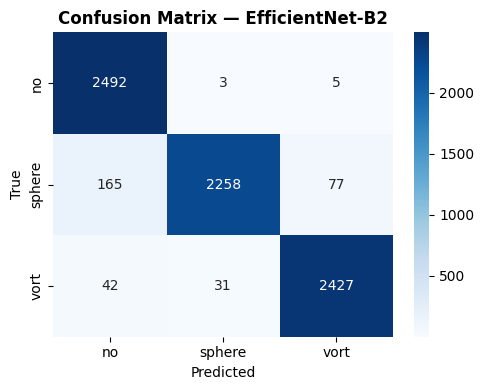

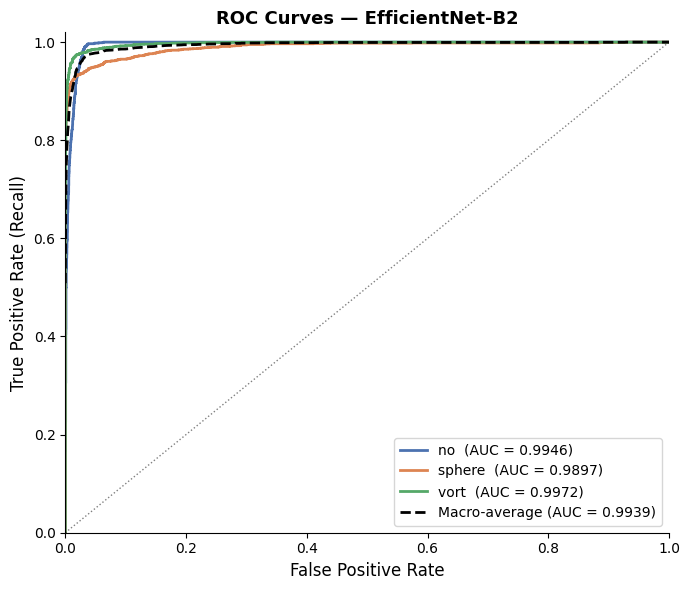

In [19]:
results_B = full_evaluation(effnet_model, val_loader_C, 'EfficientNet-B2')

---
## Approach C — Soft-Voting Ensemble (ResNet-18 + EfficientNet-B2)
Average the softmax outputs of the two best checkpoints. Both models must use the **same val loader** (224px). EfficientNet val loader is re-created at 224px for ensemble compatibility.

In [20]:
# Re-create val loader at 224px for ensemble (common resolution)
_, val_loader_224, _ = make_dataloaders({**CFG, 'img_size': 224})

# Reload checkpoints
resnet_ens = build_resnet18(NUM_CLASSES)
resnet_ens.load_state_dict(
    torch.load(CKPT_DIR / 'resnet18_resume.pt',
               map_location=DEVICE, weights_only=False)['model']
)
resnet_ens = resnet_ens.to(DEVICE)

effnet_ens = build_efficientnet_b2(NUM_CLASSES)
effnet_ens.load_state_dict(
    torch.load(CKPT_DIR / 'effnet_resume.pt',
               map_location=DEVICE, weights_only=False)['model']
)
effnet_ens = effnet_ens.to(DEVICE)

print('Checkpoints loaded.')

  Caching 30,000 images from /kaggle/input/datasets/akhiljasson/ml4sci-common-test/dataset/train into RAM ... done in 60s
  Caching 7,500 images from /kaggle/input/datasets/akhiljasson/ml4sci-common-test/dataset/val into RAM ... done in 15s
Train : 30,000 samples | Val/Test: 7,500 samples
Classes: {'no': 0, 'sphere': 1, 'vort': 2}
Batch shape: torch.Size([32, 3, 224, 224])  dtype: torch.float32  range: [-2.12, 2.62]
Checkpoints loaded.


In [21]:
@torch.no_grad()
def ensemble_predict(models_list, loader, weights=None):
    """
    Soft-voting ensemble over a list of models.
    weights: list of floats summing to 1; None = equal weighting.
    """
    if weights is None:
        weights = [1.0 / len(models_list)] * len(models_list)

    all_labels = []
    all_probs  = [np.zeros((0, NUM_CLASSES)) for _ in models_list]

    for m in models_list: m.eval()

    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        batch_probs = []
        for m in models_list:
            with torch.amp.autocast('cuda'):
                logits = m(imgs)
            batch_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
        for i, bp in enumerate(batch_probs):
            all_probs[i] = np.vstack([all_probs[i], bp]) if all_probs[i].shape[0] else bp
        all_labels.append(labels.numpy())

    labels_arr = np.concatenate(all_labels)
    ensemble_probs = sum(w * p for w, p in zip(weights, all_probs))
    return ensemble_probs, labels_arr


ens_probs, ens_labels = ensemble_predict([resnet_ens, effnet_ens], val_loader_224)
ens_acc = (ens_probs.argmax(axis=1) == ens_labels).mean()
ens_probs = ens_probs.astype(np.float64)
ens_probs = ens_probs / ens_probs.sum(axis=1, keepdims=True)
ens_auc = roc_auc_score(ens_labels, ens_probs, multi_class='ovr', average='macro')
print(f'Ensemble — Accuracy: {ens_acc:.4f} | Macro-AUC: {ens_auc:.4f}')

Ensemble — Accuracy: 0.9347 | Macro-AUC: 0.9854


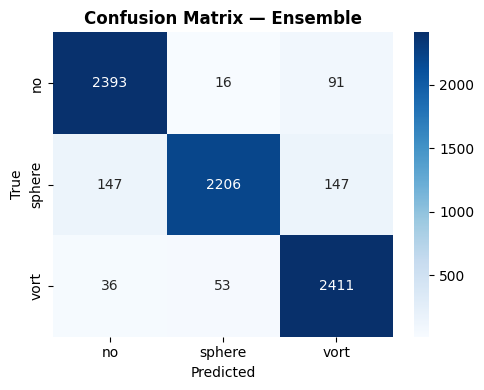

              precision    recall  f1-score   support

          no       0.93      0.96      0.94      2500
      sphere       0.97      0.88      0.92      2500
        vort       0.91      0.96      0.94      2500

    accuracy                           0.93      7500
   macro avg       0.94      0.93      0.93      7500
weighted avg       0.94      0.93      0.93      7500



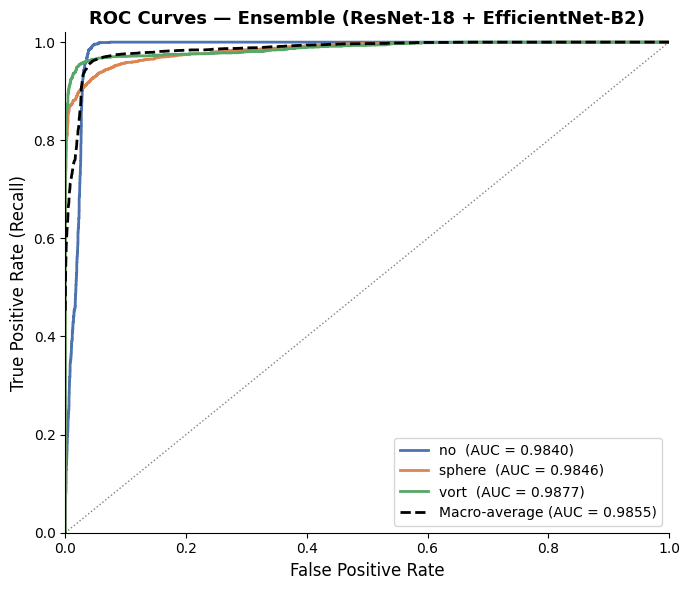

In [22]:
# Confusion matrix for ensemble
ens_preds = ens_probs.argmax(axis=1)
cm_ens = confusion_matrix(ens_labels, ens_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_ens, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=[IDX_TO_CLASS[i] for i in range(NUM_CLASSES)],
            yticklabels=[IDX_TO_CLASS[i] for i in range(NUM_CLASSES)])
ax.set_title('Confusion Matrix — Ensemble', fontweight='bold')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cm_Ensemble.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(ens_labels, ens_preds,
                             target_names=[IDX_TO_CLASS[i] for i in range(NUM_CLASSES)]))

auc_dict_D = plot_roc(ens_probs, ens_labels, 'Ensemble (ResNet-18 + EfficientNet-B2)',
                      save_path=OUTPUT_DIR / 'roc_Ensemble.png')

---
## 9. Final Results Comparison

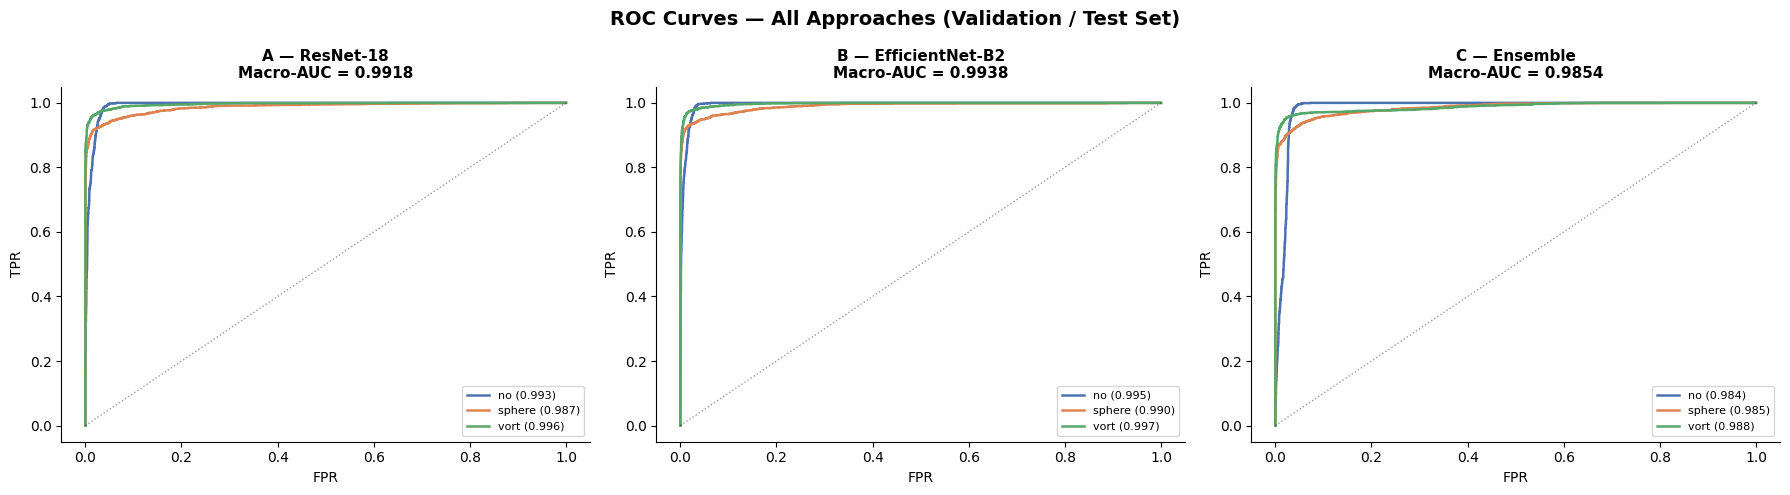

In [23]:
# ── Side-by-side ROC comparison ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
approach_data = [
    ('A — ResNet-18',                     results_A['probs'], results_A['labels']),
    ('B — EfficientNet-B2',               results_B['probs'], results_B['labels']),
    ('C — Ensemble',     ens_probs,          ens_labels),
]
colours = ['#4C72B0', '#DD8452', '#55A868']
class_labels = [IDX_TO_CLASS[i] for i in range(NUM_CLASSES)]

for ax, (name, probs, labels) in zip(axes, approach_data):
    labels_bin = label_binarize(labels, classes=[0, 1, 2])
    probs = probs.astype(np.float64)
    probs = probs / probs.sum(axis=1, keepdims=True)
    macro_auc_val = roc_auc_score(labels, probs, multi_class='ovr', average='macro')
    for i, (cls, col) in enumerate(zip(class_labels, colours)):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=1.8, label=f'{cls} ({roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k:', lw=1, alpha=0.4)
    ax.set_title(f'{name}\nMacro-AUC = {macro_auc_val:.4f}', fontweight='bold', fontsize=11)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=8, loc='lower right')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('ROC Curves — All Approaches (Validation / Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# ── Summary table ─────────────────────────────────────────────────
summary = pd.DataFrame([
    {
        'Approach'        : 'A — ResNet-18',
        'Accuracy'        : f"{results_A['acc']:.4f}",
        'Macro-AUC'       : f"{results_A['macro_auc']:.4f}",
        'AUC (no)'        : f"{results_A['per_class_auc'].get('no', float('nan')):.4f}",
        'AUC (sphere)'    : f"{results_A['per_class_auc'].get('sphere', float('nan')):.4f}",
        'AUC (vort)'      : f"{results_A['per_class_auc'].get('vort', float('nan')):.4f}",
    },
    {
        'Approach'        : 'B — EfficientNet-B2 ⭐',
        'Accuracy'        : f"{results_B['acc']:.4f}",
        'Macro-AUC'       : f"{results_B['macro_auc']:.4f}",
        'AUC (no)'        : f"{results_B['per_class_auc'].get('no', float('nan')):.4f}",
        'AUC (sphere)'    : f"{results_B['per_class_auc'].get('sphere', float('nan')):.4f}",
        'AUC (vort)'      : f"{results_B['per_class_auc'].get('vort', float('nan')):.4f}",
    },
    {
        'Approach'        : 'C — Ensemble (A + B)',
        'Accuracy'        : f'{ens_acc:.4f}',
        'Macro-AUC'       : f'{ens_auc:.4f}',
        'AUC (no)'        : f"{auc_dict_D.get('no', float('nan')):.4f}",
        'AUC (sphere)'    : f"{auc_dict_D.get('sphere', float('nan')):.4f}",
        'AUC (vort)'      : f"{auc_dict_D.get('vort', float('nan')):.4f}",
    },
])

print('\n' + '='*70)
print('  FINAL RESULTS — All Approaches on Val/Test Set')
print('='*70)
print(summary.to_string(index=False))
summary.to_csv(OUTPUT_DIR / 'results_summary.csv', index=False)
print(f'\nAll outputs saved to: {OUTPUT_DIR}')


  FINAL RESULTS — All Approaches on Val/Test Set
             Approach Accuracy Macro-AUC AUC (no) AUC (sphere) AUC (vort)
        A — ResNet-18   0.9492    0.9918   0.9926       0.9867     0.9960
B — EfficientNet-B2 ⭐   0.9569    0.9938   0.9946       0.9897     0.9972
 C — Ensemble (A + B)   0.9347    0.9854   0.9840       0.9846     0.9877

All outputs saved to: /kaggle/working/outputs


In [25]:
# ── Final outputs summary ─────────────────────────────────────────────────────
# All files are already saved to /kaggle/working/outputs/ throughout training.
# To download: Kaggle sidebar → Output → Download, or commit the notebook to
# publish outputs as a Kaggle dataset.
print("Files saved to /kaggle/working/outputs/:")
for f in sorted(OUTPUT_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<45} {size_kb:>8.1f} KB')

print("\nCheckpoints in /kaggle/working/checkpoints/:")
for f in sorted(CKPT_DIR.iterdir()):
    size_mb = f.stat().st_size / 1024 / 1024
    print(f'  {f.name:<45} {size_mb:>8.1f} MB')


Files saved to /kaggle/working/outputs/:
  class_distribution.png                            39.6 KB
  cm_EfficientNet-B2.png                            33.2 KB
  cm_Ensemble.png                                   32.8 KB
  cm_ResNet-18.png                                  33.9 KB
  history_effnet.png                                86.1 KB
  history_resnet.png                                92.0 KB
  results_summary.csv                                0.2 KB
  roc_EfficientNet-B2.png                           78.6 KB
  roc_Ensemble.png                                  87.0 KB
  roc_ResNet-18.png                                 80.1 KB
  roc_comparison_all.png                           104.0 KB
  sample_images.png                                978.4 KB

Checkpoints in /kaggle/working/checkpoints/:
  effnet_resume.pt                                  88.9 MB
  resnet18_resume.pt                               129.6 MB
